# A Comprehension of Intelligent Document Processing

Intelligent Document Processing (IDP) is an advanced automation technology that transforms the way businesses handle documents. By leveraging artificial intelligence (AI), IDP systems can automatically read, understand, and process vast quantities of documents, extracting crucial data and feeding it into various business workflows. This technology is a significant leap from traditional Optical Character Recognition (OCR) as it not only digitizes text but also comprehends the context and structure of the information within documents.

At its core, IDP is designed to tackle the challenge of processing unstructured and semi-structured data, which make up a large portion of business documents such as invoices, contracts, emails, and forms. By automating the extraction and interpretation of this data, IDP significantly reduces the need for manual data entry, leading to increased efficiency, higher accuracy, and substantial cost savings.

<br><br>

---
<br><br>

### The Inner Workings of Intelligent Document Processing

The power of IDP lies in its sophisticated multi-step process that intelligently handles documents from ingestion to data delivery. This process typically involves several key stages:

**1. Document Ingestion:** The first step involves importing documents from various sources and in multiple formats, including scanned paper documents, PDFs, Word files, and images.

**2. Pre-processing:** To enhance the quality of the input, documents undergo a pre-processing stage. This includes techniques like noise reduction, image enhancement, and deskewing to improve the accuracy of subsequent data extraction.

**3. Document Classification:** Using machine learning algorithms, the IDP system automatically categorizes documents based on their layout and content. This allows the system to differentiate between an invoice, a purchase order, or a legal contract, for instance.

**4. Data Extraction:** This is the core function of IDP. Advanced AI technologies, including Natural Language Processing (NLP) and computer vision, are employed to identify and extract relevant data fields. For example, from an invoice, it can pull out the invoice number, date, vendor name, and line-item details.

**5. Data Validation:** The extracted data is then validated against predefined rules and existing databases to ensure accuracy and consistency. Any exceptions or discrepancies can be flagged for human review in a "human-in-the-loop" process, which also helps to train and improve the AI model over time.

**6. Integration:** Finally, the structured and validated data is seamlessly integrated into downstream business systems such as Enterprise Resource Planning (ERP), Customer Relationship Management (CRM), or other databases, making the information readily available for further processing and analysis.


From **finance departments** automating invoice processing and expense management to **healthcare organizations** streamlining patient record management and claims processing, IDP is proving to be a game-changer. Even  **human resources** can expedite resume screening and employee onboarding. As the technology continues to evolve, its applications are expected to expand even further, solidifying its role as a cornerstone of modern digital transformation.

# Our Approach

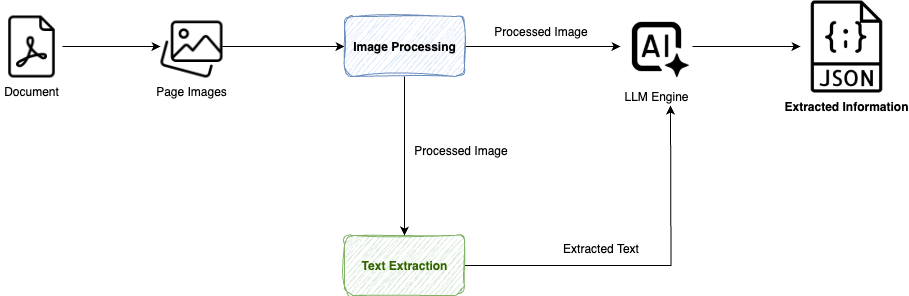

# SROIEv2: The Receipts Dataset

## Getting the data

In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [60]:
! cat /kaggle/input/resume-dataset/Resume/Resume.csv

Streaming output truncated to the last 5000 lines.
    ""> <span class=""dates_wrapper""> <span class=""jobdates"" format=""%m/%Y"" id=""589575060JSTD2""> 05/1985</span> <span>  - </span> <span class=""jobdates"" format=""%m/%Y"" id=""589575060EDDT2""> 09/2009</span> </span> <div class=""singlecolumn""> <span class=""paddedline"" itemscope="""" itemtype=""https://schema.org/postalAddress""> <span class=""companyname"" id=""589575060COMP2"" itemprop=""name""> Company Name</span> <span class=""joblocation jobcity"" id=""589575060JCIT2"" itemprop=""addressLocality""> </span> <span class=""joblocation jobstate"" id=""589575060JSTA2"" itemprop=""addressRegion""> </span> </span> <span class=""paddedline""> <span class=""jobtitle"" id=""589575060JTIT2""> Chief Warrant Officer Four</span> <span> </span> </span> <span class=""paddedline""> <span class=""jobline"" id=""589575060JDES2"" itemprop=""description""> <p align=""LEFT""> detailed with directing Forward Operating Base personnel in Kuwait

Since these are single-paged images already, we don't need to convert them

## Image Preprocesing: OpenCV

In [61]:
! pip install opencv-python matplotlib numpy

In [62]:
pip install pdf2image

In [63]:
!apt-get update
!apt-get install -y poppler-utils

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

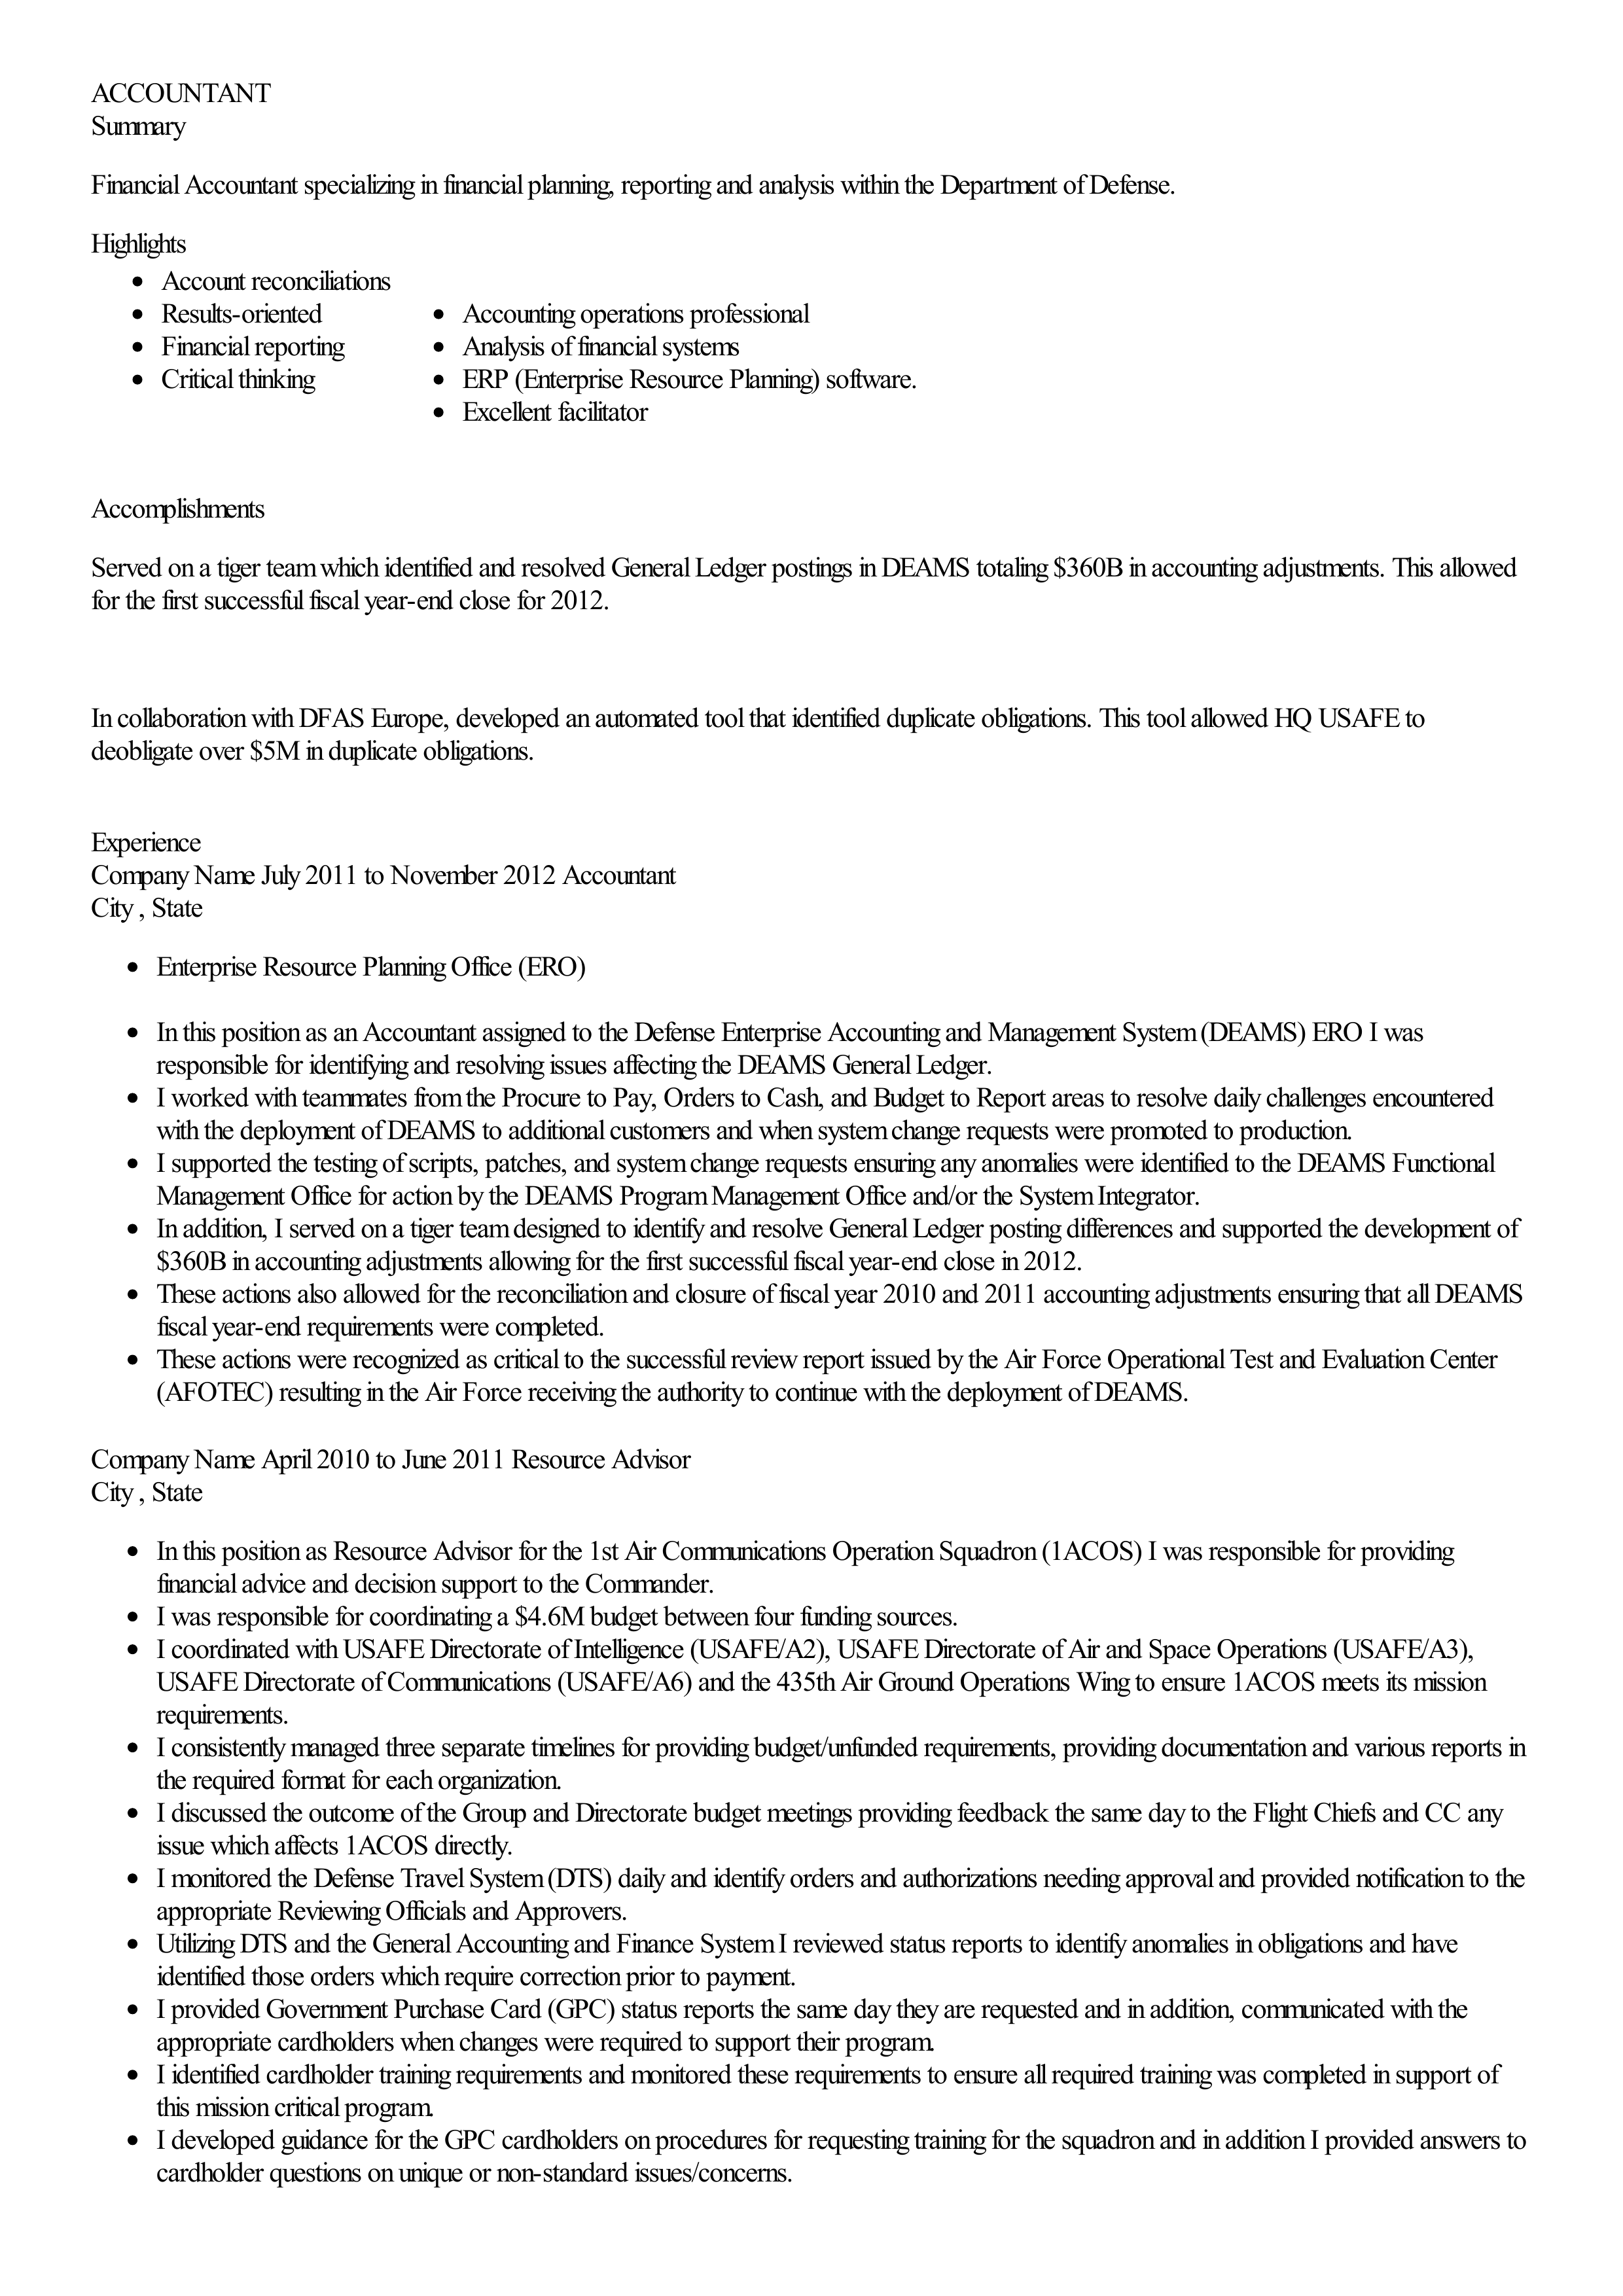

error: OpenCV(4.12.0) /io/opencv/modules/highgui/src/window.cpp:1367: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvWaitKey'


In [65]:
    from pdf2image import convert_from_path
    import cv2
    from google.colab.patches import cv2_imshow
    import numpy as np

    # Path to your PDF file
    pdf_path = '/kaggle/input/resume-dataset/data/data/ACCOUNTANT/10554236.pdf'

    # Convert PDF pages to a list of PIL Image objects
    # You can specify dpi for higher resolution images
    pages = convert_from_path(pdf_path, dpi=300)

    # Process each page
    for i, page in enumerate(pages):
        # Convert PIL Image to a NumPy array (OpenCV format)
        # Note: PIL images are typically RGB, OpenCV expects BGR
        img_cv2 = np.array(page)
        img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_RGB2BGR)

        img = cv2.imread(f'Page {i+1}', img_cv2)

        # Now you can use img_cv2 with OpenCV functions
        # For example, display the image
        cv2_imshow(img)
        cv2.waitKey(0)

    cv2.destroyAllWindows()

Let's take one image and play with it.

In [66]:
import os
#one_image_path = os.path.join(path, 'SROIE2019', 'train', 'img', 'X51005453729.jpg')
one_image_path=(img)

In [67]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def display_image(image, title="Image"):
    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

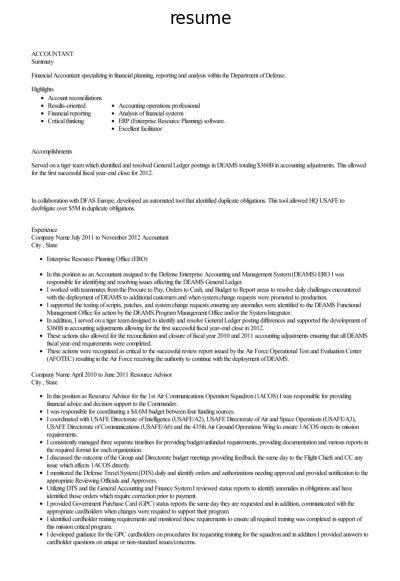

In [68]:
# one_image = cv2.imread(one_image_path)
display_image(img, "resume")

### Grayscale Conversion

**Why?** Color information is usually not necessary for reading the text on a receipt. Converting the image to grayscale simplifies it from three color channels (Red, Green, Blue) to a single channel (intensity/brightness). This reduces computational complexity and is a required first step for many subsequent operations like thresholding.

In [69]:
# Convert the image to grayscale
def convert_to_grayscale(img):
  return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

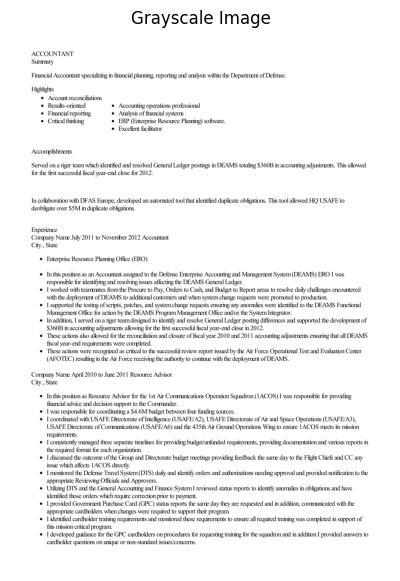

In [70]:
grayscale_image = convert_to_grayscale(img)
display_image(grayscale_image, "Grayscale Image")

### Noise (blur) Reduction
**Why?** Scanned images or photos often contain "noise" (random variations in brightness or color). This can look like small specks or graininess, which can confuse OCR algorithms. Applying a slight blur helps to smooth out this noise. A **Gaussian blur** is a common choice as it effectively averages out pixel values with a weighted average, preserving edges better than a simple blur.

In [71]:
def reduce_noise(gray_image):
  return cv2.GaussianBlur(gray_image, (5, 5), 0)

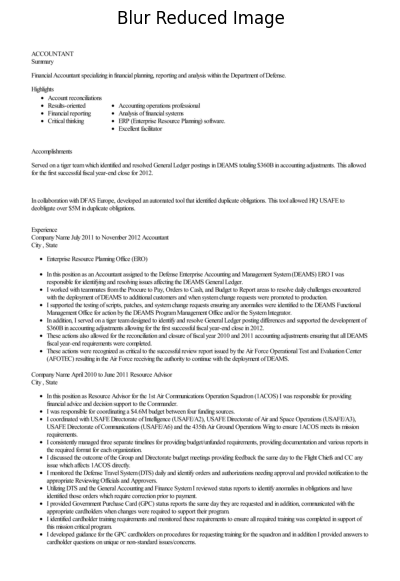

In [72]:
blur_reduced_image = reduce_noise(grayscale_image)
display_image(blur_reduced_image, "Blur Reduced Image")

### Binarization (Thresholding)

**Why?** This is one of the most critical steps. Binarization converts the grayscale image into a pure black-and-white image. The goal is to make the text **black** and the background **white**. However, receipts often have uneven lighting or shadows, so a simple (global) threshold won't work well. We use **adaptive thresholding**, which calculates a different threshold for smaller regions of the image, making it robust to lighting changes.

`cv2.adaptiveThreshold()`:

  * `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: Calculates the threshold for a pixel based on a weighted sum of neighborhood values.
  * `cv2.THRESH_BINARY_INV`: Inverts the result. We want the text to be white pixels (value 255) and the background black (value 0) for the next step (skew correction), which often works by finding white pixel contours.
  * `11`: The size of the neighborhood area (block size).
  * `4`: A constant subtracted from the mean. It's a fine-tuning parameter.

In [73]:
def binarize_image(blur_reduced_image):
  return cv2.adaptiveThreshold(
    blur_reduced_image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, # Invert the colors (text becomes white)
    11, # Block size
    4  # Constant C
  )

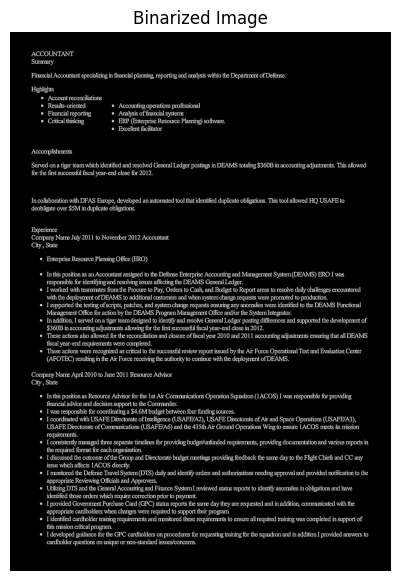

In [74]:
binarized_image = binarize_image(blur_reduced_image)
display_image(binarized_image, "Binarized Image")

### Skew Correction

**Why?** Receipts are often scanned or photographed at a slight angle. This skew can significantly reduce the accuracy of OCR. We need to detect this angle and rotate the image to make the text perfectly horizontal.

A common technique is to find the angle of the minimum-area bounding box that encloses all the text (the white pixels in our binarized image) and then rotate the original image by that angle.

In [75]:
def deskew_image(image):
    """
    Corrects the skew of an image by finding the minimum area rectangle
    of the text block and rotating accordingly.
    """
    # Find all non-zero (white) pixels
    coords = cv2.findNonZero(image)

    # Get the minimum area bounding rectangle
    # It returns (center(x,y), (width, height), angle of rotation)
    rect = cv2.minAreaRect(coords)
    angle = rect[-1] - 90

    # The `cv2.minAreaRect` angle has a specific range.
    # We need to adjust it for our rotation.
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = angle

    # Get the rotation matrix and rotate the image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_CUBIC,
                             borderMode=cv2.BORDER_REPLICATE)
    print(f"Detected skew angle: {angle:.2f} degrees")

    # Now, rotate the original grayscale image by the same angle
    (h, w) = rotated.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_gray = cv2.warpAffine(rotated, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)

    return deskewed_gray

In [76]:
deskewed_image = deskew_image(binarized_image)

Detected skew angle: -0.48 degrees


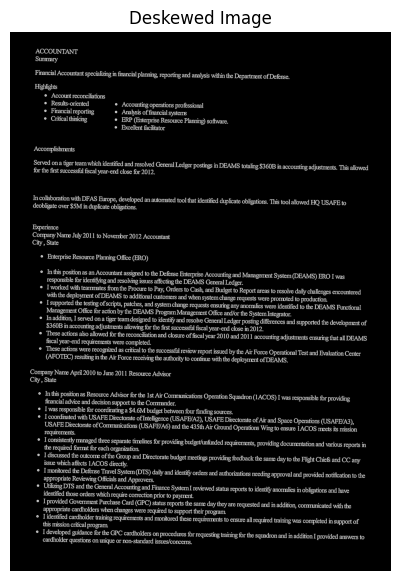

In [77]:
display_image(deskewed_image, "Deskewed Image")

In [85]:
import os

directory_path = "/content/processed_images"

if not os.path.exists(directory_path):
    os.mkdir(directory_path)
    print(f"Directory '{directory_path}' created.")
else:
    print(f"Directory '{directory_path}' already exists.")

Directory '/content/processed_images' already exists.


In [79]:
cv2.imwrite(f"/content/processed_images/1.jpg", deskewed_image)

True

Let's run the above code for all images

In [80]:
def process_one_image(image):
  image = convert_to_grayscale(image)
  print("Converted image to grayscale..")
  image = reduce_noise(image)
  print("Reduced noise in the image..")
  image = binarize_image(image)
  print("Binarized the image..")
  image = deskew_image(image)
  print("Corrected image orientation..")
  return image

In [81]:
!cp -r /kaggle/input/resume-dataset/data/data/ACCOUNTANT /content/ACCOUNTANT

In [82]:
    import shutil
    import os

    # Replace 'my_folder' with the actual name of your folder in Colab
    folder_to_download = '/content/ACCOUNTANT'
    zip_file_name = f'{folder_to_download}.zip'

    # Create the zip archive
    shutil.make_archive(folder_to_download, 'zip', folder_to_download)

'/content/ACCOUNTANT.zip'

In [83]:
from pdf2image import convert_from_path
import os
from google.colab import files

output_folder = "/content/converted_images"
os.makedirs(output_folder, exist_ok=True)

uploaded = files.upload()

for filename in uploaded.keys():
    if filename.lower().endswith('.pdf'):
        print(f"Converting {filename}...")
        try:
            images = convert_from_path(filename, dpi=300) # Adjust DPI as needed
            for i, image in enumerate(images):
                image_filename = os.path.join(output_folder, f"{os.path.splitext(filename)[0]}_page_{i+1}.jpg")
                image.save(image_filename, 'JPEG')
            print(f"Successfully converted {filename} to images in '{output_folder}'.")
        except Exception as e:
            print(f"Error converting {filename}: {e}")
    else:
        print(f"Skipping {filename} as it's not a PDF file.")

Saving 10554236.pdf to 10554236 (1).pdf
Saving 10674770.pdf to 10674770 (1).pdf
Saving 11163645.pdf to 11163645 (1).pdf
Saving 11759079.pdf to 11759079 (1).pdf
Saving 12065211.pdf to 12065211 (1).pdf
Saving 12202337.pdf to 12202337 (1).pdf
Saving 12338274.pdf to 12338274 (1).pdf
Saving 12442909.pdf to 12442909 (1).pdf
Saving 12780508.pdf to 12780508 (1).pdf
Saving 12802330.pdf to 12802330 (1).pdf
Saving 13072019.pdf to 13072019 (1).pdf
Saving 13130984.pdf to 13130984 (1).pdf
Saving 13294301.pdf to 13294301 (1).pdf
Saving 13491889.pdf to 13491889 (1).pdf
Saving 13701259.pdf to 13701259 (1).pdf
Saving 14055988.pdf to 14055988 (1).pdf
Saving 14126433.pdf to 14126433 (1).pdf
Saving 14224370.pdf to 14224370 (1).pdf
Saving 14449423.pdf to 14449423 (1).pdf
Saving 14470533.pdf to 14470533 (1).pdf
Saving 14491649.pdf to 14491649 (1).pdf
Saving 14496667.pdf to 14496667 (1).pdf
Saving 15289348.pdf to 15289348 (1).pdf
Saving 15363277.pdf to 15363277 (1).pdf
Saving 15592167.pdf to 15592167 (1).pdf


# All FIles can be saved to a location if required wrt below code

import time
output_folder_path = "/content/processed_images"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")


for image_name in os.listdir(os.path.join('content', 'converted_images'))[:20]:
    print(f"Processing image: {image_name}")
    image_path = os.path.join('content', 'converted_images', image_name)
    image = cv2.imread(image_path)
    processed_image = process_one_image(image)
  # save image
    output_path = os.path.join(output_folder_path, image_name)
    cv2.imwrite(output_path, processed_image)
  print(f"Saved processed image to: {output_path}")
  print("-"*50)

print("Processing images is completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

## Text Extraction: Tesseract

Tesseract OCR is a powerful and widely-used open-source optical character recognition (OCR) engine. In simple terms, it's a software that can "read" text from images and convert it into machine-readable text. This means you can take a picture of a document, a sign, or any other object containing text, and Tesseract can extract that text so you can edit, search, or analyze it.

### A Brief History and Development

Originally developed by Hewlett-Packard in the 1980s, Tesseract was later open-sourced in 2005 and has been sponsored by Google since 2006. This has led to significant improvements and made it one of the most accurate and versatile free OCR engines available. The latest versions of Tesseract utilize long short-term memory (LSTM), a type of recurrent neural network (RNN), which has greatly enhanced its ability to recognize text with high accuracy.



### Core Functionalities and Capabilities

Tesseract boasts a rich set of features that make it a flexible tool for various applications:

  * **Extensive Language Support:** Tesseract can recognize over 100 languages, making it a truly global OCR solution. It also supports multiple scripts and can even be trained to recognize new languages.
  * **Multiple Output Formats:** It can output the recognized text in various formats, including plain text, HTML, PDF, and TSV (tab-separated values). This allows for easy integration with other software and workflows.
  * **Page Segmentation Modes:** Tesseract offers different page segmentation modes, which help in correctly identifying the layout of a document, including columns, paragraphs, and blocks of text.
  * **Character Recognition and Confidence:** Not only does it recognize characters, but it can also provide a confidence score for each recognized character, word, or line. This is useful for assessing the accuracy of the OCR process.
  * **Command-Line and API Access:** Tesseract can be used as a command-line tool for quick and simple OCR tasks. For more complex integrations, it provides an API that allows developers to incorporate its OCR capabilities into their own applications. Popular wrappers like Pytesseract make it easy to use Tesseract with programming languages like Python.


### Installation
`pip install pytesseract pillow`


### How to Use Tesseract

For developers, integrating Tesseract into an application is straightforward using its API. Here is a simple example using the `pytesseract` wrapper in Python:

```python

from PIL import Image
import pytesseract


text = pytesseract.image_to_string(Image.open(filename))

print(text)
```



### Common Use Cases and Applications

The ability to extract text from images opens up a vast range of applications across various industries:

  * **Document Digitization:** Converting scanned documents, books, and historical archives into searchable digital text.
  * **Data Entry Automation:** Automating the process of entering data from invoices, receipts, and forms.
  * **Accessibility:** Assisting visually impaired individuals by converting printed text into speech.
  * **License Plate Recognition:** In law enforcement and traffic management systems.
  * **Social Media Monitoring:** Analyzing text within images shared on social media platforms.
  * **Translation:** Extracting text from an image and then using a translation service to translate it.

While Tesseract is a powerful tool, the accuracy of its output heavily depends on the quality of the input image. For best results, images should be clear, well-lit, and have a high resolution. Pre-processing steps like resizing, noise reduction, and converting to grayscale can significantly improve OCR accuracy.

In [87]:
! pip install pytesseract pillow

In [88]:
from PIL import Image
import pytesseract

pytesseract.image_to_string(Image.open('/content/processed_images/1.jpg'))

'ACCOUNTANT\n\nSummary\nFinancial Accountant specializing in financial PUB eee HC EWS AZELI NE Doorttnrenme a Da creel\nHighlights\n\n° Account reconciliations\n\n© Results-oriented ° Accounting operations professional\n\n° Financial reporting SPAS Remi e AES (Ores\n\n° Critical thinking ° ERP (Enterprise Resource Planning) software.\n\n° Excellent facilitator\n\nAccomplishments\n\nServed on a tiger team which identified and resolved General Ledger postings in DEAMS totaling $360B in accounting adjustments. This allowed\nfor the first successfill fiscal year-end close for 2012,\n\nSree ye eee R SDS SB SOM all once MET CeR Rian erro duplicate obligations. This tool allowed HQ USAFE to\ndeobligate over $5M in duplicate obligations.\n\nExperience\nCompany Name July 2011 to November 2012 Accountant\n\nCity , State\n° Enterprise Resource Planning Office (ERO)\n\n° In this position as an Accountant assigned to the Defense 1S oS gee PeuMOnUlie cee B\\CTUA Cctv eHmS Se crety (DEAMS) ERO I was\

In [89]:
from PIL import Image
import pytesseract
import time

input_folder_path = "/content/processed_images"
output_folder_path = "/content/tesseract_output"
start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(input_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print("Extracting text from image..")
  text = pytesseract.image_to_string(Image.open(image_path))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".txt"))
  with open(output_path, "w") as f:
    f.write(text)

  print(f"Saved extracted text to {output_path}")
  print("-"*50)

print("Text Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

Total images in folder: 1
Processing image 1/1: 1.jpg
Extracting text from image..
Saved extracted text to /content/tesseract_output/1.txt
--------------------------------------------------
Text Extraction Completed.
Total time taken: 17.560781717300415 seconds


## Information Extraction

In [90]:
prompt = """
Extract the information from the given image.
Information to be extracted: summary.
The image has been converted to grayscale, noise reduced, binarized, and deskewed using opencv.
Always give your response in the following format:
{
    "summary": "Summary",

}
Also, the text has been extracted from the image using tesseract.
Use the extracted text as support for extracting information.
If you believe the extraction is incorrect somewhere, you may correct it yourself and provide corrected information.
Respond with the extracted information only in the specified format.
Here is the text:


"""

Can we improve the prompt using the [Unified Framework For An Effective Prompt](https://www.geeksforgeeks.org/data-science/a-unified-framework-for-an-effective-prompt/)?

In [91]:
from google import genai
from google.colab import userdata # colab only code
from PIL import Image
import json
import time

In [92]:
genai_client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

In [96]:
 pip install --upgrade google-generativeai

In [98]:
    import google.generativeai as genai

    # Replace 'your_api_key' with your actual API key
    genai.configure(api_key="GOOGLE_API_KEY")

    # This example uses a placeholder for a currently available model.
    # Replace 'gemini-1.5-pro-latest' with an actual, currently supported model name.
    model = genai.GenerativeModel('gemini-1.5-pro-latest')

# Further query can be executed after installation of gemini-1.5-flash v1beta

image_folder_path = "/content/processed_images"
text_folder_path = "/content/tesseract_output"
output_folder_path = "/content/json_output"

start_time = time.time()

if os.makedirs(output_folder_path, exist_ok=True):
  print(f"Created folder: {output_folder_path}")

total_images = sum(1 for entry in os.scandir(image_folder_path))
print(f"Total images in folder: {total_images}")

for i, image_name in enumerate(os.listdir(input_folder_path)[:20], 1):
  print(f"Processing image {i}/{total_images}: {image_name}")
  image_path = os.path.join(input_folder_path, image_name)
  print(f"Loading image: {image_path}")
  with open(image_path, "rb") as f:
    image = Image.open(image_path)


  text_path = os.path.join(text_folder_path, image_name.replace(".jpg", ".txt"))
  print(f"Loading extracted text: {text_path}")
  with open(text_path, "r") as f:
    text = f.read()

  print("Extracting information from image and text..")

  prompt = prompt + text



  contents = [
        image,
        {
            "text": prompt
        }
    ]
  response = genai_client.models.generate_content(model='gemini-1.5-flash', contents=contents)

  # Access the usage_metadata attribute
  usage_metadata = response.usage_metadata

  # Print the different token counts
  print(f"Input Token Count: {usage_metadata.prompt_token_count}")
  print(f"Thoughts Token Count: {response.usage_metadata.thoughts_token_count}")
  print(f"Output Token Count: {usage_metadata.candidates_token_count}")
  print(f"Total Token Count: {usage_metadata.total_token_count}")

  extracted_information = json.loads(response.text.replace('```json', '').replace('```', ''))
  output_path = os.path.join(output_folder_path, image_name.replace(".jpg", ".json"))
  with open(output_path, "w") as f:
    json.dump(extracted_information, f, indent=4)

  print(f"Saved extracted information to {output_path}")
  print("-"*50)
  time.sleep(60)

print("Information Extraction Completed.")
print(f"Total time taken: {time.time() - start_time} seconds")

# Can you play with a Resume Dataset?

https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset